# EDA và lựa chọn pseudo-entity

Notebook này trình bày lại kết quả đánh giá pseudo-entity đã được duyệt ở Giai đoạn 1. Mục tiêu là chuyển báo cáo từ script sang notebook; không quét lại dữ liệu raw và không đánh giá thêm candidate mới.

## Phương pháp đã sử dụng

Mỗi candidate ghép các cột bằng dấu `|`, chỉ tạo UID khi mọi cột thành phần đều khác `NULL`, sau đó băm MD5. Báo cáo đã có so sánh độ phủ, số entity, tỷ lệ entity lặp, tỷ lệ dòng thuộc entity lặp, trung vị, phân vị 95% và số giao dịch lớn nhất trên mỗi entity.

Ba candidate bắt buộc theo đặc tả là `card1 + addr1`, `card1 + card2 + addr1` và `card1 + card2 + addr1 + D1`. Báo cáo legacy còn có đối chứng `card1 + card2 + card5 + addr1`; notebook giữ nguyên dòng này để tái tạo đúng kết quả đã duyệt.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

project_root = Path.cwd()
if not (project_root / 'reports' / 'entity_candidate_results.csv').exists():
    project_root = project_root.parent

source_report_path = project_root / 'reports' / 'entity_candidate_results.csv'
output_report_path = project_root / 'artifacts' / 'reports' / 'entity_candidate_results.csv'
selected_candidate = 'card1_card2_addr1'
selected_columns = 'card1 + card2 + addr1'

source_report_path, output_report_path

(WindowsPath('c:/Users/tiennd49/Documents/point-in-time-feature-store/reports/entity_candidate_results.csv'),
 WindowsPath('c:/Users/tiennd49/Documents/point-in-time-feature-store/artifacts/reports/entity_candidate_results.csv'))

## Kết quả đã được duyệt

Cell dưới đây đọc báo cáo legacy, kiểm tra schema và xác nhận candidate đã chọn trước khi trình bày.

In [2]:
results = pd.read_csv(source_report_path)

required_columns = {
    'candidate', 'columns', 'total_rows', 'rows_with_uid',
    'coverage_pct', 'n_entities', 'repeat_entity_pct',
    'repeat_row_pct', 'median_txn_per_entity',
    'p95_txn_per_entity', 'max_txn_per_entity',
    'selected', 'selection_reason',
}
assert required_columns <= set(results.columns)
assert len(results) == 4

selected = results.loc[results['selected']]
assert selected['candidate'].tolist() == [selected_candidate]
assert selected['columns'].tolist() == [selected_columns]

print(results.to_string(index=False))

              candidate                       columns  total_rows  rows_with_uid  coverage_pct  n_entities  repeat_entity_pct  repeat_row_pct  median_txn_per_entity  p95_txn_per_entity  max_txn_per_entity  selected                                                                                                                                                     selection_reason
card1_card2_card5_addr1 card1 + card2 + card5 + addr1      590540         514655         87.15       38143              60.58           97.08                    2.0                  43                5866     False                                                                                                                                                                  NaN
            card1_addr1                 card1 + addr1      590540         524834         88.87       37531              60.52           97.18                    2.0                  45                5885     False                          

## So sánh trực quan

Độ phủ cho biết tỷ lệ giao dịch tạo được UID; tỷ lệ entity lặp cho biết candidate có đủ lịch sử để xây rolling feature hay không. Candidate chứa `D1` bị phân mảnh rõ rệt dù độ phủ vẫn tương đương các candidate còn lại.

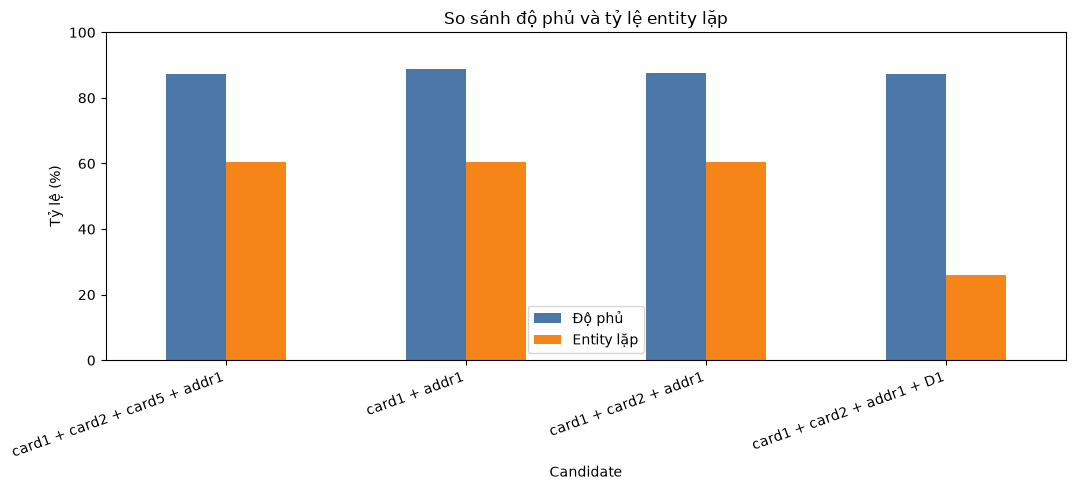

In [3]:
plot_data = results.set_index('columns')[['coverage_pct', 'repeat_entity_pct']]
ax = plot_data.plot(
    kind='bar',
    figsize=(11, 5),
    color=['#4C78A8', '#F58518'],
)
ax.set_title('So sánh độ phủ và tỷ lệ entity lặp')
ax.set_xlabel('Candidate')
ax.set_ylabel('Tỷ lệ (%)')
ax.set_ylim(0, 100)
ax.legend(['Độ phủ', 'Entity lặp'])
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## Quyết định

Chọn **`card1 + card2 + addr1`**. Candidate này cân bằng độ phủ **87,45%**, tỷ lệ entity lặp **60,49%** và tỷ lệ dòng thuộc entity lặp **97,15%**; chi tiết hơn `card1 + addr1` nhưng không bị phân mảnh mạnh như candidate có `D1`.

In [4]:
output_report_path.parent.mkdir(parents=True, exist_ok=True)
results.to_csv(output_report_path, index=False)

exported = pd.read_csv(output_report_path)
pd.testing.assert_frame_equal(exported, results, check_dtype=False)

print(f'Đã export: {output_report_path}')
print(f'Candidate được chọn: {selected_columns}')

Đã export: c:\Users\tiennd49\Documents\point-in-time-feature-store\artifacts\reports\entity_candidate_results.csv
Candidate được chọn: card1 + card2 + addr1
